# **Bi-Directional Occupancy Intelligence System**

## The Goal
The aim of this project is to build a smart camera system that automatically tracks how many people enter and leave a building. Instead of just seeing a crowd, the system understands direction, helping managers know exactly how many people are inside at any given moment.

---

## Problem Statement & Resolution
* **The Manual Burden:** Counting people by hand is slow, expensive, and prone to human error.
* **The "Direction" Challenge:** Standard cameras can see a person, but they don't know if that person is coming or going.
* **The Solution:** We use **AI "memory."** The system gives every person a unique ID and watches their path. If they cross a digital line moving forward, they are counted as **"In"**; if they move backward, they are counted as **"Out."**

---

## Key Features
* **Real-Time Detection:** Recognizes people instantly as they appear on screen.
* **Directional Counting:** Automatically sorts foot traffic into "In" and "Out" categories.
* **Smart Tracking:** Keeps track of the same person even if they are briefly blocked by a door or another person.
* **Live Occupancy:** Provides a live total of how many people are currently in the room.

---

## Tools Used
| Tool | Purpose |
| :--- | :--- |
| **Python** | The main programming language and logic of the project. |
| **YOLOv8** | A powerful AI model famous for recognizing objects at high speeds. |
| **OpenCV** | The library that helps the computer process video frames and draw counting lines. |

# **IMPORTING LIBRARIES**

This section loads all required libraries for data handling, visualization, and model training.

In [35]:
# Import Libraries

import os
import cv2
import yaml
import csv
import random
import shutil
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from collections import defaultdict
from ultralytics import YOLO

import warnings
warnings.filterwarnings('ignore')

# **LOADING THE DATASET**

## Loading The Dataset

We inspect the dataset structure to ensure images and labels are correctly organized for YOLO training.

In [36]:
print(os.getcwd())

/home/kagendo/Desktop/YOLO_People_Counting_System/training


In [37]:
DATASET_PATH = r"/home/kagendo/Desktop/YOLO_People_Counting_System/training/data"

for root, dirs, files in os.walk(DATASET_PATH):
    print(f"{root} -> {len(files)} files")
print_tree(DATASET_PATH)

/home/kagendo/Desktop/YOLO_People_Counting_System/training/data -> 0 files
/home/kagendo/Desktop/YOLO_People_Counting_System/training/data/train -> 0 files
/home/kagendo/Desktop/YOLO_People_Counting_System/training/data/train/data -> 15211 files
/home/kagendo/Desktop/YOLO_People_Counting_System/training/data/valid -> 0 files
/home/kagendo/Desktop/YOLO_People_Counting_System/training/data/valid/valid -> 1432 files
data/
    train/
        data/
            000108_jpg.rf.cf69a1e17689a2a7998255f0ab592f31.jpg
            fourth_034_png_jpg.rf.e83d391edfbe2f04d7dd1dd9ffdf2887.jpg
            2008_001504_jpg.rf.c5ee5c4e34a920979ba3272930739c5b.jpg
            fourth_032_png_jpg.rf.5fad28d971436a122425dcf4bdaa8186.jpg
            2008_006294_jpg.rf.85445c3a7d2e3c4cb2a9a77f17f17229.jpg
            131_person_jpg.rf.375225e68b157b1399ba0fb428122ea9.jpg
            000048_jpg.rf.dfcc0e6224df6b6da315e531bb1e1f41.jpg
            2008_008148_jpg.rf.de896ce533be3b79a544401f4ba9a683.jpg
            2

### From the above output;

**Data Distribution**
* **Training Set:** 15,211 files
* **Validation Set:** 1,432 files

**Structural Observation**
The dataset uses a **nested folder structure**. The primary `train` and `valid` directories are empty; all images are located in the sub-directories:
* `.../train/data/`
* `.../valid/valid/`

**Action Required**
The `data.yaml` configuration must point directly to these specific sub-folders to prevent training errors.

# **DATA EXPLORATION**

In [43]:
df = pd.read_csv("/home/kagendo/Desktop/YOLO_People_Counting_System/training/data/train/data/_annotations.csv")
print(df.head())
print(df.info())
print(df.describe())
print(f"Total annotations: {len(df)}")

                                            filename  width  height   class  \
0  2008_003132_jpg.rf.92f6223defec4f57f2d7b9cfa28...    500     375  person   
1  2008_003132_jpg.rf.92f6223defec4f57f2d7b9cfa28...    500     375  person   
2  2008_003132_jpg.rf.92f6223defec4f57f2d7b9cfa28...    500     375  person   
3  004574_jpg.rf.7c8cea69d7be45f58febcede26ef0c6e...    500     333  person   
4  004574_jpg.rf.7c8cea69d7be45f58febcede26ef0c6e...    500     333  person   

   xmin  ymin  xmax  ymax  
0   219    98   269   283  
1   114   124   155   263  
2    43   139    98   340  
3   145   118   229   333  
4   285   105   349   329  
<class 'pandas.DataFrame'>
RangeIndex: 100082 entries, 0 to 100081
Data columns (total 8 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   filename  100082 non-null  str  
 1   width     100082 non-null  int64
 2   height    100082 non-null  int64
 3   class     100082 non-null  str  
 4   xmin      100082 non-null

### **Training Data Report**

**Data Summary**
* **Total Annotations:** 100,082
* **Integrity:** 100% complete (Zero null values).
* **Target Class:** "person" (Confirmed).

**Key Observations**
* **High Resolution:** Supports a wide range of image sizes (up to 4624px), allowing for diverse environmental training.
* **Crowd Density:** Multiple labels per file confirm the dataset is suitable for high-occupancy counting.
* **Coordinate Validity:** All bounding boxes are within image boundaries.

**Next Step**
Convert the 100,082 CSV entries into YOLO-standard `.txt` files to begin the training phase.

In [44]:
df = pd.read_csv("/home/kagendo/Desktop/YOLO_People_Counting_System/training/data/valid/valid/_annotations.csv")
print(df.head())
print(df.info())
print(df.describe())
print(f"Total annotations: {len(df)}")

                                            filename  width  height   class  \
0  BSMT1XOO121P_jpg.rf.3172b37162bba43942f1a82395...    500     375  person   
1  point03_140_png_jpg.rf.4166a3ba6f32cf3fad662d2...   1280     720  person   
2  point03_140_png_jpg.rf.4166a3ba6f32cf3fad662d2...   1280     720  person   
3  point01_179_png_jpg.rf.4b397a9403192a0c286c5f3...   1280     720  person   
4  2010_003325_jpg.rf.9caa17b2dd1dade077477d4ae80...    500     375  person   

   xmin  ymin  xmax  ymax  
0   254   136   350   304  
1   406   138   609   488  
2   681     0   711   101  
3   836   244   976   579  
4   213    40   476   316  
<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   filename  10683 non-null  str  
 1   width     10683 non-null  int64
 2   height    10683 non-null  int64
 3   class     10683 non-null  str  
 4   xmin      10683 non-null  int64
 

### **Validation Data Report**

**Data Summary**
* **Total Annotations:** 10,683
* **Integrity:** 100% complete (Zero null values).
* **Target Class:** "person" (Confirmed).

**Key Observations**
* **Scaling Consistency:** Average resolution ($1464 \times 893$) aligns well with the training set, ensuring the model generalizes across similar aspect ratios.
* **Precision Distribution:** The validation set includes high-definition $1920 \times 1080$ and $2048 \times 1152$ samples, providing a rigorous test for small-object detection at higher resolutions.
* **Structural Readiness:** The bounding box distribution ($xmin$ to $ymax$) follows the same logic as the training data, confirming a clean split.

**Next Step**
Synchronize these validation annotations with the training labels for conversion to YOLO `.txt` format. The system is ready to benchmark baseline performance.

# **CLEANING THE DATA**

In [46]:
# Paths based on your specific nested structure
TRAIN_CSV = os.path.join(DATASET_PATH, "train/data/_annotations.csv")
TRAIN_IMG_DIR = os.path.join(DATASET_PATH, "train/data")

VAL_CSV = os.path.join(DATASET_PATH, "valid/valid/_annotations.csv")
VAL_IMG_DIR = os.path.join(DATASET_PATH, "valid/valid")

# Target Sample Sizes
SAMPLES = {
    "train": 1500,
    "val": 300
}

def process_dataset(csv_path, src_img_dir, split_name):
    print(f"--- Starting {split_name} sampling & conversion ---")
    
    # 1. Load Data
    df = pd.read_csv(csv_path)
    all_images = df['filename'].unique().tolist()
    
    # 2. Random Sampling
    sample_size = min(len(all_images), SAMPLES[split_name])
    sampled_images = random.sample(all_images, sample_size)
    
    # Filter for chosen images
    df_sampled = df[df['filename'].isin(sampled_images)]
    
    out_img_dir = f"yolo_dataset/{split_name}/images"
    out_lbl_dir = f"yolo_dataset/{split_name}/labels"

    # 3. Processing Loop
    for img_name in sampled_images:
        src_path = os.path.join(src_img_dir, img_name)
        if not os.path.exists(src_path):
            continue

        # Copy Image file
        shutil.copy(src_path, os.path.join(out_img_dir, img_name))

        # Create corresponding YOLO .txt file
        basename = os.path.splitext(img_name)[0]
        label_path = os.path.join(out_lbl_dir, f"{basename}.txt")
        
        image_annots = df_sampled[df_sampled['filename'] == img_name]
        
        with open(label_path, "w") as f:
            for _, row in image_annots.iterrows():
                # Normalized YOLO Coordinates: [class x_center y_center width height]
                x_center = ((row['xmin'] + row['xmax']) / 2) / row['width']
                y_center = ((row['ymin'] + row['ymax']) / 2) / row['height']
                w = (row['xmax'] - row['xmin']) / row['width']
                h = (row['ymax'] - row['ymin']) / row['height']
                
                f.write(f"0 {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}\n")

# --- EXECUTION ---

# Ensure a clean directory for the new sampled dataset
if os.path.exists("yolo_dataset"):
    shutil.rmtree("yolo_dataset")

for split in ['train', 'val']:
    os.makedirs(f"yolo_dataset/{split}/images", exist_ok=True)
    os.makedirs(f"yolo_dataset/{split}/labels", exist_ok=True)

# Process both splits
process_dataset(TRAIN_CSV, TRAIN_IMG_DIR, "train")
process_dataset(VAL_CSV, VAL_IMG_DIR, "val")

print("\n✅ Success: 1800 total images sampled and converted in 'yolo_dataset/'")

--- Starting train sampling & conversion ---
--- Starting val sampling & conversion ---

✅ Success: 1800 total images sampled and converted in 'yolo_dataset/'


In [47]:
def count_files(directory):
    return len([f for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))])

train_imgs = count_files("yolo_dataset/train/images")
train_lbls = count_files("yolo_dataset/train/labels")
val_imgs = count_files("yolo_dataset/val/images")
val_lbls = count_files("yolo_dataset/val/labels")

print(f"📊 Training: {train_imgs} images, {train_lbls} labels")
print(f"📊 Validation: {val_imgs} images, {val_lbls} labels")

if train_imgs == train_lbls and val_imgs == val_lbls:
    print("✅ Success: Image and label counts match.")
else:
    print("❌ Warning: Mismatch between images and labels!")

📊 Training: 1500 images, 1500 labels
📊 Validation: 300 images, 300 labels
✅ Success: Image and label counts match.


In [48]:
label_files = os.listdir("yolo_dataset/train/labels")
random_label = random.choice(label_files)

print(f"📄 Checking content of: {random_label}")
with open(f"yolo_dataset/train/labels/{random_label}", "r") as f:
    lines = f.readlines()
    for line in lines:
        print(f"   Content: {line.strip()}")
        # Basic check: class should be 0 and values should be < 1
        parts = line.split()
        if float(parts[1]) > 1.0 or float(parts[2]) > 1.0:
            print("❌ Error: Coordinates are not normalized!")

📄 Checking content of: 2010_002484_jpg.rf.63ba3e07ce57e3268fe6a99410157dca.txt
   Content: 0 0.966000 0.408967 0.064000 0.122283
   Content: 0 0.421000 0.760870 0.194000 0.472826
   Content: 0 0.898000 0.642663 0.200000 0.709239
   Content: 0 0.580000 0.630435 0.236000 0.733696


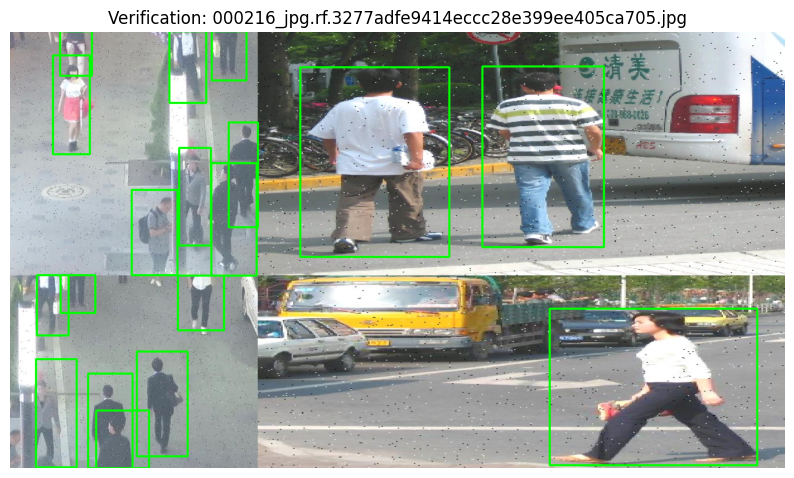

In [ ]:
def plot_random_sample(img_dir, lbl_dir):
    img_name = random.choice(os.listdir(img_dir))
    img_path = os.path.join(img_dir, img_name)
    lbl_path = os.path.join(lbl_dir, os.path.splitext(img_name)[0] + ".txt")

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape

    with open(lbl_path, "r") as f:
        for line in f:
            cls, x, y, bw, bh = map(float, line.split())
            # Convert back from normalized to pixel coordinates
            x1 = int((x - bw/2) * w)
            y1 = int((y - bh/2) * h)
            x2 = int((x + bw/2) * w)
            y2 = int((y + bh/2) * h)
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 3)

    plt.figure(figsize=(10, 6))
    plt.imshow(image)
    plt.title(f"Verification: {img_name}")
    plt.axis('off')
    plt.show()

# Run visual check
plot_random_sample("yolo_dataset/train/images", "yolo_dataset/train/labels")

# **DATA PREPARATION**

# **MODEL SELECTION**

# **MODELTRAINING/FINE TUNING**

# **HYPERPARAMETER TUNING**

# **MODEL SAVING**

# **MODEL EVALUTION**

# **INFERENCE**

# **PEOPLE COUNTING LOGIC**

# **VISUALIZATION**

# **DEPLOYMENT**